In [204]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, average_precision_score, ConfusionMatrixDisplay

In [169]:
def load_data(filepath):
    df = pd.read_csv(filepath)
    return df

In [195]:
df = load_data(filepath='../data/Heart_Disease_Prediction.csv')

In [196]:
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


Since the assignment requires only one feature,The input feature is selected as cholesterol.

In [197]:
df.shape

(270, 14)

#### Numerical analysis of data

In [198]:
df.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000


#### Checking null and duplicate values

In [199]:
df.isnull().sum()

Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

No null values found.

In [200]:
df.duplicated().sum()

np.int64(0)

No duplicated values found.

#### Checking the data types

In [201]:
df.dtypes

Age                          int64
Sex                          int64
Chest pain type              int64
BP                           int64
Cholesterol                  int64
FBS over 120                 int64
EKG results                  int64
Max HR                       int64
Exercise angina              int64
ST depression              float64
Slope of ST                  int64
Number of vessels fluro      int64
Thallium                     int64
Heart Disease                  str
dtype: object

In [208]:
encoder = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")

In [218]:
df[['Heart Disease']] = encoder.fit_transform(df[['Heart Disease']]).astype(int)
df['Heart Disease'].head(2)


0    1
1    0
Name: Heart Disease, dtype: int64

#### Separating feature and target variables

Text(0.5, 1.0, 'Correlation among different features')

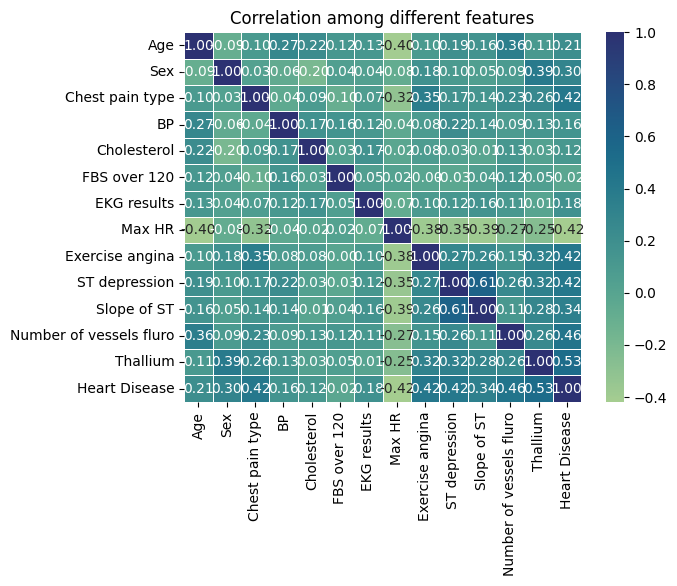

In [219]:
sns.heatmap(df.corr(), annot=True, fmt=".2f", linewidths=.5, cmap="crest")
plt.title("Correlation among different features")

#### we will use cholesterol as the feature as instructed in the assignment as we found a positive correlation between cholesterol and the target.

#### Univariate Analysis

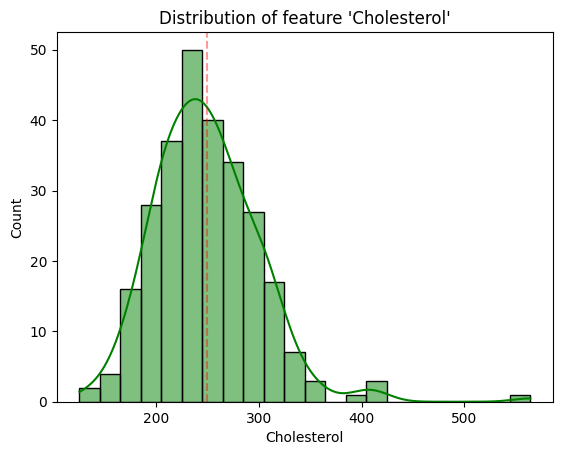

In [225]:
sns.histplot(df, x="Cholesterol", color='g', kde=True)
plt.title("Distribution of feature 'Cholesterol'")
plt.axvline(df['Cholesterol'].mean(), color='r',linestyle="--", alpha=0.4)
plt.show()

In [226]:
feature = df[['Cholesterol']]
target = df[['Heart Disease']]

#### Splitting the data into training and testing sets

In [227]:
x_train, x_test, y_train, y_test = train_test_split(feature,target, test_size=0.3, random_state=42, stratify=target)

In [228]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((189, 1), (81, 1), (189, 1), (81, 1))

#### Training the logistic regression model

In [229]:
x_train_scaled = StandardScaler().fit_transform(x_train)
x_test_scaled = StandardScaler().fit_transform(x_test)
print("trained_scaled: ", x_train_scaled[:3])
print("test_scaled: ", x_test_scaled[:3])

trained_scaled:  [[-0.71738509]
 [-1.2997821 ]
 [-0.07862708]]
test_scaled:  [[-0.58308374]
 [-0.64685032]
 [ 0.98982532]]


In [184]:
from sklearn.linear_model import LogisticRegression

In [ ]:
logistic_model = LogisticRegression(C=np.inf, random_state=42)
logistic_model.fit(x_train_scaled, y_train)

In [231]:
logistic_model.coef_

array([[0.14315357]])

In [232]:
y_pred = logistic_model.predict(x_test_scaled)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1])

In [233]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.56      0.96      0.70        45
           1       0.50      0.06      0.10        36

    accuracy                           0.56        81
   macro avg       0.53      0.51      0.40        81
weighted avg       0.53      0.56      0.44        81



Confusion Matrix
[[43  2]
 [34  2]]


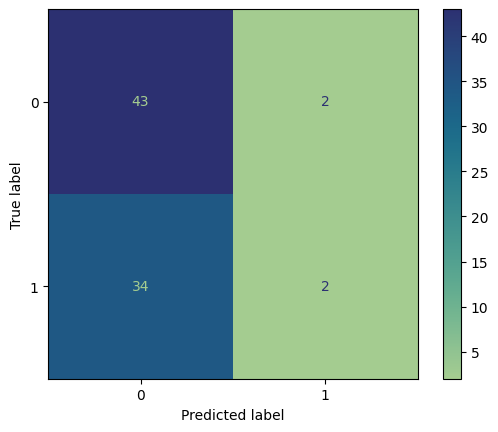

In [236]:
print("Confusion Matrix")
confusion_mat = confusion_matrix(y_true=y_test, y_pred=y_pred)
ConfusionMatrixDisplay(confusion_matrix=confusion_mat).plot(cmap="crest")
print(confusion_mat)

As the goal of this task is heart disease prediction, priority is given to minimizing false negatives. Therefore, the model should maximize the identification of patients with heart disease, while a relatively higher false-positive rate can be accepted.

In [237]:
y_score = logistic_model.predict_proba(x_test_scaled)[:, 1]

Average Precision Score: 0.580


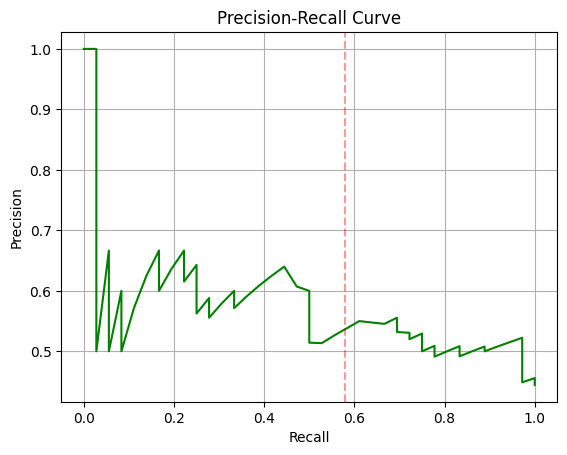

In [238]:
precision, recall, _ = precision_recall_curve(y_test, y_score)
pr_auc = average_precision_score(y_test, y_score)
plt.plot(recall, precision, color='g')
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.axvline(pr_auc, color='r', alpha=0.4, linestyle='--')
print(f"Average Precision Score: {pr_auc:.3f}")

When we catch almost 100% of patients with heart disease, our precision is around 20%.